<a href="https://colab.research.google.com/github/MinhPhuc1401/Mobile-Game-AB-Testing-Analysis/blob/main/cookie_cats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/cookie_cats.csv')

In [ ]:
display(df.head())

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [6]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


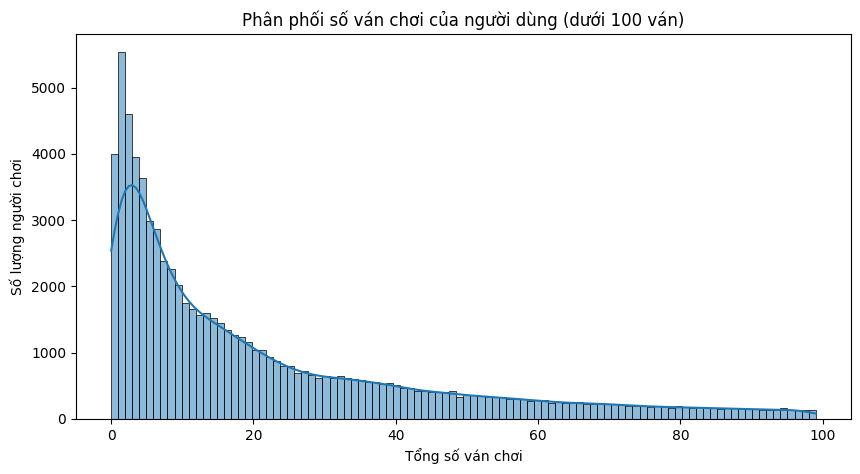

In [7]:
df_cleaned = df[df['sum_gamerounds'] < df['sum_gamerounds'].max()]

plt.figure(figsize=(10, 5))
sns.histplot(data=df_cleaned[df_cleaned['sum_gamerounds'] < 100], x='sum_gamerounds', bins=100, kde=True)
plt.title('Phân phối số ván chơi của người dùng (dưới 100 ván)')
plt.xlabel('Tổng số ván chơi')
plt.ylabel('Số lượng người chơi')
plt.show()

In [15]:
combined_summary = df_cleaned.groupby('version').agg(
    player_count=('userid', 'count'),
    retention_1=('retention_1', 'mean'),
    retention_7=('retention_7', 'mean')
)

combined_summary[['retention_1', 'retention_7']] = (combined_summary[['retention_1', 'retention_7']] * 100).round(2)

combined_summary = combined_summary.rename(columns={
    'player_count': 'Total Players',
    'retention_1': 'Retention D1 (%)',
    'retention_7': 'Retention D7 (%)'
})

display(combined_summary)

,Total Players,Retention D1 (%),Retention D7 (%)
version,,,
gate_30,44699,44.82,19.02
gate_40,45489,44.23,18.20


In [16]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_cleaned['version'], df_cleaned['retention_7'])
display(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chỉ số p-value: {p_value:.5f}")

if p_value < 0.05:
    print("=> Kết luận: Có sự khác biệt CÓ Ý NGHĨA THỐNG KÊ.")
    print("=> Việc đổi Gate sang level 40 THỰC SỰ làm GIẢM tỷ lệ giữ chân người chơi.")
else:
    print("=> Kết luận: KHÔNG có sự khác biệt có ý nghĩa thống kê.")
    print("=> Sự chênh lệch chỉ là ngẫu nhiên, đổi Gate sang 40 không ảnh hưởng gì.")

retention_7,False,True
version,,
gate_30,36198,8501
gate_40,37210,8279


Chỉ số p-value: 0.00164
=> Kết luận: Có sự khác biệt CÓ Ý NGHĨA THỐNG KÊ.
=> Việc đổi Gate sang level 40 THỰC SỰ làm GIẢM tỷ lệ giữ chân người chơi.
